In [ ]:
import os, re, math, string, glob
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Any
from dataclasses import dataclass

import numpy as np
import h5py
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.9.0+cu126
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## Data Structure Explorer

### What to expect
```
hdf5_data_final/
  t15.2023.08.13/
    data_train.hdf5   ← groups: 'trial_0', 'trial_1', ...
      trial_0/
        input_features  shape=(T, 512)  float32   ← neural spike-band power
        attrs['sentence_label'] = 'the cat sat on the mat'
```

In [ ]:
def explore_data(data_dir: str):
    data_path = Path(data_dir)
    if not data_path.exists():
        print(f'[ERROR] data_dir does not exist: {data_dir}')
        print('  → Check that the Brain-to-Text 25 competition dataset is mounted.')
        print('    Expected path: /kaggle/input/brain-to-text-25/...')
        return

    # List session folders
    sessions = sorted(data_path.glob('t15.*'))
    print(f'Found {len(sessions)} session folder(s) under {data_dir}')
    for s in sessions[:5]:
        files = list(s.glob('*.hdf5'))
        print(f'  {s.name}/ → {[f.name for f in files]}')
    if len(sessions) > 5:
        print(f'  ... ({len(sessions) - 5} more)')

    # Inspect first train file
    train_files = sorted(data_path.glob('t15.*/data_train.hdf5'))
    if not train_files:
        print('[WARN] No data_train.hdf5 found. Data might not be mounted.')
        return

    print(f'\nInspecting: {train_files[0]}')
    with h5py.File(train_files[0], 'r') as f:
        keys = list(f.keys())
        print(f'  Top-level trial keys (first 5): {keys[:5]}  ... ({len(keys)} total)')
        first_key = keys[0]
        trial = f[first_key]
        print(f'  Trial "{first_key}" datasets: {list(trial.keys())}')
        if 'input_features' in trial:
            feat = trial['input_features']
            print(f'    input_features shape : {feat.shape}  dtype={feat.dtype}')
            print(f'    input_features stats : mean={feat[:].mean():.4f}  std={feat[:].std():.4f}')
        print(f'  Trial attributes: {dict(trial.attrs)}')


explore_data(CFG.data_dir)

Found 45 session folder(s) under /kaggle/input/competitions/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final
  t15.2023.08.11/ → ['data_train.hdf5']
  t15.2023.08.13/ → ['data_test.hdf5', 'data_train.hdf5', 'data_val.hdf5']
  t15.2023.08.18/ → ['data_test.hdf5', 'data_train.hdf5', 'data_val.hdf5']
  t15.2023.08.20/ → ['data_test.hdf5', 'data_train.hdf5', 'data_val.hdf5']
  t15.2023.08.25/ → ['data_test.hdf5', 'data_train.hdf5', 'data_val.hdf5']
  ... (40 more)

Inspecting: /kaggle/input/competitions/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5
  Top-level trial keys (first 5): ['trial_0000', 'trial_0001', 'trial_0002', 'trial_0003', 'trial_0004']  ... (288 total)
  Trial "trial_0000" datasets: ['input_features', 'seq_class_ids', 'transcription']
    input_features shape : (321, 512)  dtype=float32
    input_features stats : mean=-0.0001  std=0.9993
  Trial attributes: {'block_num': np.int64(2), 'n_time_steps': np.int64(321), 'sentence_

## Character Tokenizer

### Vocabulary (36 tokens)
| ID | Token | Notes |
|---|---|---|
| 0 | `<blank>` | CTC blank — never appears in decoded output |
| 1 | `<PAD>` | Padding — ignored by loss |
| 2 | `<BOS>` | Begin of sequence — fed as first decoder token |
| 3 | `<EOS>` | End of sequence — decoder stops when predicted |
| 4–29 | `a–z` | Lowercase letters |
| 30 | `<space>` | Word separator |
| 31–35 | `' . , ! ?` | Basic punctuation |

In [4]:
"""
CELL 4 — Character-level Tokenizer
"""
class CharTokenizer:
    BLANK_ID    = 0   # CTC blank
    PAD_ID      = 1   # padding
    BOS_ID      = 2   # begin of sequence
    EOS_ID      = 3   # end of sequence
    SPECIAL_IDS = {0, 1, 2, 3}

    def __init__(self):
        self.chars: List[str] = ['<blank>', '<PAD>', '<BOS>', '<EOS>']
        self.chars += list(string.ascii_lowercase)    # ids 4..29
        self.chars += [' ', "'", '.', ',', '!', '?']  # ids 30..35

        self.char2id: Dict[str, int] = {c: i for i, c in enumerate(self.chars)}
        self.id2char: Dict[int, str] = {i: c for i, c in enumerate(self.chars)}
        self.vocab_size: int = len(self.chars)  # 36

    def encode(self, text: str, add_bos_eos: bool = True) -> torch.Tensor:
        """text → token-ID tensor, optionally wrapped with BOS/EOS."""
        text = text.lower().strip()
        ids = [self.BOS_ID] if add_bos_eos else []
        for ch in text:
            ids.append(self.char2id.get(ch, self.char2id[' ']))
        if add_bos_eos:
            ids.append(self.EOS_ID)
        return torch.tensor(ids, dtype=torch.long)

    def encode_ctc(self, text: str) -> torch.Tensor:
        """
        Encode WITHOUT BOS/EOS — used as CTC target.
        CTC loss does NOT use BOS/EOS special tokens.
        """
        return self.encode(text, add_bos_eos=False)

    def decode(self, ids, remove_special: bool = True) -> str:
        """token-IDs → string (stops at EOS, optionally removes special tokens)."""
        if isinstance(ids, torch.Tensor):
            ids = ids.cpu().tolist()
        chars = []
        for i in ids:
            if i == self.EOS_ID:
                break
            if remove_special and i in self.SPECIAL_IDS:
                continue
            ch = self.id2char.get(i, '')
            if remove_special and ch.startswith('<'):
                continue
            chars.append(ch)
        return ''.join(chars)

    def ctc_decode_greedy(self, log_probs: torch.Tensor) -> List[str]:
        """
        Greedy CTC decode.

        Algorithm:
          1. argmax over vocab at every time step → (B, T)
          2. Collapse consecutive duplicate tokens
          3. Remove BLANK tokens (id=0)
          4. Decode remaining IDs to string

        Args:
            log_probs: (B, T, V)  — log-softmax output from CTC head
        Returns:
            List[str] of length B
        """
        preds = log_probs.argmax(dim=-1)  # (B, T)
        results = []
        for seq in preds:
            seq = seq.cpu().tolist()
            # Step 2: collapse consecutive duplicates
            collapsed, prev = [], -1
            for t in seq:
                if t != prev:
                    collapsed.append(t)
                prev = t
            # Step 3: remove blanks
            clean = [t for t in collapsed if t != self.BLANK_ID]
            # Step 4: decode
            results.append(self.decode(clean, remove_special=True))
        return results


# ── Tests ──────────────────────────────────────────────────────────
tokenizer = CharTokenizer()
print(f'Vocab size : {tokenizer.vocab_size}')

sample = 'hello world'
enc    = tokenizer.encode(sample)
print(f"encode('{sample}')     → {enc.tolist()}")
print(f"decode back            → '{tokenizer.decode(enc)}'")

ctc_enc = tokenizer.encode_ctc(sample)
print(f"encode_ctc('{sample}') → {ctc_enc.tolist()} (no BOS/EOS)")

assert tokenizer.decode(enc) == sample, 'Round-trip encode/decode failed'
print('Tokenizer tests passed.')

Vocab size : 36
encode('hello world')     → [2, 11, 8, 15, 15, 18, 30, 26, 18, 21, 15, 7, 3]
decode back            → 'hello world'
encode_ctc('hello world') → [11, 8, 15, 15, 18, 30, 26, 18, 21, 15, 7] (no BOS/EOS)
Tokenizer tests passed.


## Cell 5 — Dataset & Augmentation

### How the Dataset Works
- Reads `input_features` (shape `T × 512`) from each trial group in the HDF5 files
- Reads `sentence_label` attribute as the ground-truth text
- Returns two targets per trial:
  - `tokens` — BOS + char IDs + EOS (for the **attention decoder**)
  - `ctc_tgt` — char IDs only (for **CTC loss**, no special tokens)

### Augmentation (train only)
| Technique | Probability | Effect |
|---|---|---|
| Time masking | 40% | Zero-out 1–2 windows of 5–20 timesteps |
| Channel dropout | 25% | Drop 15% of electrode channels randomly |
| Gaussian noise | 30% | Add σ=0.05 Gaussian noise |
| Time stretch | 20% | Resample temporal axis by ±10% |

In [ ]:
class BrainToTextDataset(Dataset):
    def __init__(
        self,
        hdf5_paths : List[str],
        tokenizer  : CharTokenizer,
        mode       : str  = 'train',
        augment    : bool = True,
        max_neural : int  = 1024,
    ):
        self.tok     = tokenizer
        self.mode    = mode
        self.augment = augment and (mode == 'train')
        self.max_len = max_neural

        self.trials: List[Tuple[int, str]] = []
        self.files : Dict[int, h5py.File]  = {}

        print(f'Loading {mode} data...')
        for fi, path in enumerate(tqdm(hdf5_paths)):
            f = h5py.File(path, 'r')
            self.files[fi] = f
            for key in f.keys():
                self.trials.append((fi, key))
        print(f'  → {len(self.trials)} trials loaded')

    def __len__(self) -> int:
        return len(self.trials)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        fi, key = self.trials[idx]
        trial   = self.files[fi][key]

        # ── Neural features (T, 512) ──────────────────────────────────
        neural = torch.tensor(trial['input_features'][:], dtype=torch.float32)
        if neural.size(0) > self.max_len:
            neural = neural[: self.max_len]

        # ── Text label ────────────────────────────────────────────────
        text = trial.attrs.get('sentence_label', '') or ''
        # h5py sometimes returns bytes or numpy bytes
        if isinstance(text, (bytes, np.bytes_)):
            text = text.decode('utf-8')
        text = str(text).strip()

        tokens  = self.tok.encode(text)      # [BOS, chars..., EOS]
        ctc_tgt = self.tok.encode_ctc(text)  # [chars...] — no BOS/EOS for CTC

        # Guard: CTC target must be non-empty (CTCLoss requires len >= 1)
        if ctc_tgt.numel() == 0:
            ctc_tgt = torch.tensor([self.tok.char2id[' ']], dtype=torch.long)

        # ── Augmentation ──────────────────────────────────────────────
        if self.augment:
            neural = self._augment(neural)

        return {
            'neural'  : neural,    # (T, 512)
            'tokens'  : tokens,    # (T_text,)  attention-decoder target
            'ctc_tgt' : ctc_tgt,   # (T_ctc,)   CTC target
            'text'    : text,
        }

    def _augment(self, x: torch.Tensor) -> torch.Tensor:
        """Apply data augmentation to neural features (train only)."""
        T, C = x.shape

        # 1) Time masking (SpecAugment-style)
        if torch.rand(1).item() < 0.4:
            n_masks = torch.randint(1, 3, (1,)).item()
            for _ in range(int(n_masks)):
                mask_len = torch.randint(5, 20, (1,)).item()
                start    = torch.randint(0, max(1, T - mask_len), (1,)).item()
                x[start : start + mask_len] = 0.0

        # 2) Channel (electrode) dropout
        if torch.rand(1).item() < 0.25:
            keep = torch.bernoulli(torch.full((C,), 0.85))
            x    = x * keep.unsqueeze(0)

        # 3) Gaussian noise
        if torch.rand(1).item() < 0.3:
            x = x + torch.randn_like(x) * 0.05

        # 4) Time sub-sampling (mild stretch/compress ±10%)
        if torch.rand(1).item() < 0.2 and T > 10:
            fac   = 0.9 + 0.2 * torch.rand(1).item()  # [0.9, 1.1]
            new_T = max(10, int(T * fac))
            idx   = torch.linspace(0, T - 1, new_T).long().clamp(0, T - 1)
            x     = x[idx]

        return x


def collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Collate a list of samples into a padded batch.

    Returns a dict with:
      neural       : (B, T_max, 512)  padded neural features
      neural_mask  : (B, T_max) bool  True = PAD (encoder ignores these)
      neural_lens  : (B,) int         original neural sequence lengths
      tokens       : (B, T_text)      padded decoder targets (BOS+chars+EOS)
      ctc_tgt      : (B, T_ctc)       padded CTC targets (chars only)
      ctc_lens     : (B,) int         actual CTC target lengths
      texts        : List[str]        raw text labels
    """
    neurals  = [b['neural']   for b in batch]
    tokens_l = [b['tokens']   for b in batch]
    ctc_l    = [b['ctc_tgt']  for b in batch]
    texts    = [b['text']     for b in batch]

    neural_lens = torch.tensor([n.size(0) for n in neurals], dtype=torch.long)
    ctc_lens    = torch.tensor([c.size(0) for c in ctc_l],   dtype=torch.long)

    B     = len(neurals)
    T_max = int(neural_lens.max().item())

    # Pad neural sequences
    neural_pad = pad_sequence(neurals, batch_first=True, padding_value=0.0)  # (B, T_max, 512)

    # Build key-padding mask: True = PAD position
    neural_mask = torch.ones(B, T_max, dtype=torch.bool)   # start: all PAD
    for i in range(B):
        neural_mask[i, : int(neural_lens[i].item())] = False  # valid → False

    tokens_pad = pad_sequence(tokens_l, batch_first=True, padding_value=CharTokenizer.PAD_ID)
    ctc_pad    = pad_sequence(ctc_l,    batch_first=True, padding_value=CharTokenizer.PAD_ID)

    return {
        'neural'      : neural_pad,
        'neural_mask' : neural_mask,
        'neural_lens' : neural_lens,
        'tokens'      : tokens_pad,
        'ctc_tgt'     : ctc_pad,
        'ctc_lens'    : ctc_lens,
        'texts'       : texts,
    }


print('Dataset helpers defined.')

Dataset helpers defined.


##  Conformer Encoder

### Conformer Block structure
```
x → FF₁(½) → MHSA → ConvModule → FF₂(½) → LayerNorm → output
     ↑ each sub-module has a residual connection
```

In [6]:
"""
CELL 6 — Conformer Encoder
"""
class Swish(nn.Module):
    """Swish activation: x * sigmoid(x). Shown to work better than ReLU/GELU in Conformers."""
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.sigmoid(x)


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017)."""
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 8000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, : x.size(1)])


class ConformerConvModule(nn.Module):
    """
    Conformer depthwise-separable convolution module.

    Structure: LayerNorm → Pointwise(2D) → GLU → Depthwise → BN → Swish → Pointwise → Dropout
    The GLU gate halves the channels after the first pointwise expansion.
    """
    def __init__(self, d_model: int, kernel_size: int = 31, dropout: float = 0.1):
        super().__init__()
        assert (kernel_size - 1) % 2 == 0, 'conv_kernel must be odd for symmetric padding'
        self.ln   = nn.LayerNorm(d_model)
        self.pw1  = nn.Conv1d(d_model, 2 * d_model, 1)     # pointwise expand ×2
        self.glu  = nn.GLU(dim=1)                           # gate halves channels → d_model
        self.dw   = nn.Conv1d(                              # depthwise conv (per-channel)
            d_model, d_model, kernel_size,
            padding=(kernel_size - 1) // 2,
            groups=d_model,
        )
        self.bn   = nn.BatchNorm1d(d_model)
        self.act  = Swish()
        self.pw2  = nn.Conv1d(d_model, d_model, 1)         # pointwise project
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D)
        residual = x
        x = self.ln(x).transpose(1, 2)          # (B, D, T)
        x = self.glu(self.pw1(x))               # (B, D, T)
        x = self.act(self.bn(self.dw(x)))       # (B, D, T)
        x = self.drop(self.pw2(x)).transpose(1, 2)  # (B, T, D)
        return x + residual  # residual connection


class ConformerBlock(nn.Module):
    """
    One Conformer block with stochastic depth.

    BUG FIX from v2a: LayerNorm before MHSA is computed ONCE and reused
    for Q, K, V.  Previously called self.mhsa_ln(x) three times independently
    which is incorrect (different dropout masks would apply each time).
    """
    def __init__(
        self,
        d_model      : int,
        n_heads      : int,
        ff_expansion : int   = 4,
        conv_kernel  : int   = 31,
        dropout      : float = 0.1,
        drop_path    : float = 0.0,
    ):
        super().__init__()
        d_ff = d_model * ff_expansion

        self.ff1_ln  = nn.LayerNorm(d_model)
        self.ff1     = nn.Sequential(
            nn.Linear(d_model, d_ff), Swish(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.mhsa_ln   = nn.LayerNorm(d_model)
        self.mhsa      = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.mhsa_drop = nn.Dropout(dropout)
        self.conv      = ConformerConvModule(d_model, conv_kernel, dropout)
        self.ff2_ln    = nn.LayerNorm(d_model)
        self.ff2       = nn.Sequential(
            nn.Linear(d_model, d_ff), Swish(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.final_ln  = nn.LayerNorm(d_model)
        self.drop_path = drop_path

    def _drop(self, residual: torch.Tensor, shortcut: torch.Tensor) -> torch.Tensor:
        """Stochastic depth: randomly skip a residual branch during training."""
        if self.training and self.drop_path > 0.0:
            survive = (torch.rand(1, device=residual.device) > self.drop_path).float()
            return shortcut + residual * survive
        return shortcut + residual

    def forward(
        self,
        x                : torch.Tensor,
        key_padding_mask : Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # FF1 (half-step weight = 0.5)
        x = self._drop(0.5 * self.ff1(self.ff1_ln(x)), x)

        # MHSA — FIX: compute normed once, reuse for Q, K, V
        normed = self.mhsa_ln(x)
        attn_out, _ = self.mhsa(
            normed, normed, normed,
            key_padding_mask=key_padding_mask,
            need_weights=False,
        )
        x = self._drop(self.mhsa_drop(attn_out), x)

        # Conv module
        x = self.conv(x)

        # FF2 (half-step)
        x = self._drop(0.5 * self.ff2(self.ff2_ln(x)), x)

        return self.final_ln(x)


class ConformerEncoder(nn.Module):
    """
    Full Conformer encoder.

    Pipeline:
      Conv subsampling (stride=2) → Positional Encoding → N × ConformerBlock

    Returns:
      z        : (B, T//2, D)  encoder output
      enc_mask : (B, T//2)     padding mask (True = PAD)
    """
    def __init__(
        self,
        n_channels   : int   = 512,
        d_model      : int   = 512,
        n_layers     : int   = 8,
        n_heads      : int   = 8,
        ff_expansion : int   = 4,
        conv_kernel  : int   = 31,
        dropout      : float = 0.1,
        drop_path    : float = 0.1,
    ):
        super().__init__()
        # Temporal subsampling: reduces sequence length by 2×
        self.subsampler = nn.Sequential(
            nn.Conv1d(n_channels, d_model, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.pos_enc = PositionalEncoding(d_model, dropout, max_len=8000)

        # Linearly increase stochastic depth from 0 → drop_path across layers
        dpr = [drop_path * i / max(n_layers - 1, 1) for i in range(n_layers)]
        self.blocks = nn.ModuleList([
            ConformerBlock(d_model, n_heads, ff_expansion, conv_kernel, dropout, dp)
            for dp in dpr
        ])

    def forward(
        self,
        x    : torch.Tensor,
        mask : Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        # x: (B, T, C)  mask: (B, T) bool True=PAD
        x = x.transpose(1, 2)   # (B, C, T)
        x = self.subsampler(x)  # (B, D, T//2)
        x = x.transpose(1, 2)   # (B, T//2, D)
        L = x.size(1)

        # Downsample mask to match subsampled length
        if mask is not None:
            mask_ds = mask[:, ::2]
            if mask_ds.size(1) > L:
                mask_ds = mask_ds[:, :L]
            elif mask_ds.size(1) < L:
                pad_cols = torch.ones(
                    mask_ds.size(0), L - mask_ds.size(1),
                    dtype=torch.bool, device=mask_ds.device,
                )
                mask_ds = torch.cat([mask_ds, pad_cols], dim=1)
        else:
            mask_ds = None

        x = self.pos_enc(x)
        for block in self.blocks:
            x = block(x, key_padding_mask=mask_ds)

        return x, mask_ds  # (B, L, D), (B, L)


print('ConformerEncoder defined.')

ConformerEncoder defined.


## Attention Decoder

### Role
During training the decoder uses **teacher forcing**: it sees the ground-truth
prefix and predicts the next character.  At inference it runs **greedy autoregressive
decoding** (or CTC greedy decode from the encoder alone, which is faster).


In [ ]:

def make_causal_mask(T: int, device: torch.device) -> torch.Tensor:
    """
    Upper-triangular boolean causal mask.
    Shape: (T, T)  — True = 'do NOT attend' (future tokens are masked).

    Example for T=4:
      [[F, T, T, T],
       [F, F, T, T],
       [F, F, F, T],
       [F, F, F, F]]
    """
    return torch.triu(torch.ones(T, T, dtype=torch.bool, device=device), diagonal=1)


class AttentionDecoder(nn.Module):
    """
    Transformer decoder that cross-attends to encoder output z.

    Uses pre-LN (norm_first=True) for training stability.
    """
    def __init__(
        self,
        vocab_size   : int,
        d_model      : int   = 512,
        n_layers     : int   = 6,
        n_heads      : int   = 8,
        ff_expansion : int   = 4,
        dropout      : float = 0.1,
    ):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=CharTokenizer.PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, dropout, max_len=4000)

        dec_layer = nn.TransformerDecoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_model * ff_expansion,
            dropout         = dropout,
            activation      = 'gelu',
            batch_first     = True,
            norm_first      = True,  # pre-LN: more stable training
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.proj    = nn.Linear(d_model, vocab_size)

    def forward(
        self,
        tgt         : torch.Tensor,                    # (B, T_tgt) token ids
        memory      : torch.Tensor,                    # (B, T_enc, D) encoder output
        memory_mask : Optional[torch.Tensor] = None,   # (B, T_enc) True=PAD
    ) -> torch.Tensor:                                 # → (B, T_tgt, V)
        T = tgt.size(1)
        causal  = make_causal_mask(T, tgt.device)      # (T, T) bool
        tgt_pad = (tgt == CharTokenizer.PAD_ID)        # (B, T_tgt) bool

        emb = self.pos_enc(self.embed(tgt))
        out = self.decoder(
            emb, memory,
            tgt_mask                = causal,
            tgt_key_padding_mask    = tgt_pad,
            memory_key_padding_mask = memory_mask,
        )
        return self.proj(out)

    @torch.no_grad()
    def generate(
        self,
        memory      : torch.Tensor,
        memory_mask : Optional[torch.Tensor] = None,
        max_len     : int = 120,
        bos_id      : int = CharTokenizer.BOS_ID,
        eos_id      : int = CharTokenizer.EOS_ID,
    ) -> torch.Tensor:
        """Greedy autoregressive decoding. Returns (B, ≤ max_len+1) token IDs."""
        B      = memory.size(0)
        device = memory.device
        tokens = torch.full((B, 1), bos_id, dtype=torch.long, device=device)
        done   = torch.zeros(B, dtype=torch.bool, device=device)

        for _ in range(max_len):
            logits     = self.forward(tokens, memory, memory_mask)
            next_tok   = logits[:, -1].argmax(dim=-1, keepdim=True)  # (B, 1)
            tokens     = torch.cat([tokens, next_tok], dim=1)
            done       = done | (next_tok.squeeze(-1) == eos_id)
            if done.all():
                break

        return tokens


print('AttentionDecoder defined.')

AttentionDecoder defined.


## Full Model

In [ ]:

class DSDNLA_v2(nn.Module):
    """
    DSD-NLA v2: Direct Spectral Decoding Neural Language Architecture v2

    Components:
      1. ConformerEncoder   → z  (B, T//2, D)
      2. CTC Head           → ctc_log_probs  (B, T//2, V)
      3. AttentionDecoder   → dec_logits  (B, T_text, V)

    Joint loss = ctc_weight * CTC + (1 - ctc_weight) * CE
    """
    def __init__(self, cfg: Config, vocab_size: int):
        super().__init__()
        self.cfg = cfg

        self.encoder = ConformerEncoder(
            n_channels   = cfg.n_channels,
            d_model      = cfg.d_model,
            n_layers     = cfg.n_encoder_layers,
            n_heads      = cfg.n_heads,
            ff_expansion = cfg.ff_expansion,
            conv_kernel  = cfg.conv_kernel,
            dropout      = cfg.dropout,
            drop_path    = cfg.stochastic_depth_prob,
        )
        self.ctc_head = nn.Sequential(
            nn.LayerNorm(cfg.d_model),
            nn.Linear(cfg.d_model, vocab_size),
        )
        self.decoder = AttentionDecoder(
            vocab_size   = vocab_size,
            d_model      = cfg.d_model,
            n_layers     = cfg.n_decoder_layers,
            n_heads      = cfg.n_heads,
            ff_expansion = cfg.ff_expansion,
            dropout      = cfg.dropout,
        )

    def forward(
        self,
        neural        : torch.Tensor,
        neural_mask   : Optional[torch.Tensor] = None,
        target_tokens : Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:
        z, enc_mask = self.encoder(neural, neural_mask)
        ctc_log     = F.log_softmax(self.ctc_head(z), dim=-1)

        dec_logits = None
        if target_tokens is not None:
            dec_logits = self.decoder(target_tokens, z, enc_mask)

        return {
            'ctc_log_probs' : ctc_log,
            'enc_mask'      : enc_mask,
            'z'             : z,
            'dec_logits'    : dec_logits,
        }

    @torch.no_grad()
    def inference(
        self,
        neural      : torch.Tensor,
        neural_mask : Optional[torch.Tensor] = None,
        use_ctc     : bool = True,
        max_len     : int  = 120,
    ) -> Dict[str, Any]:
        z, enc_mask = self.encoder(neural, neural_mask)
        ctc_log     = F.log_softmax(self.ctc_head(z), dim=-1)

        tokens = None
        if not use_ctc:
            tokens = self.decoder.generate(z, enc_mask, max_len=max_len)

        return {'ctc_log_probs': ctc_log, 'tokens': tokens, 'enc_mask': enc_mask}


# ── Smoke test ─────────────────────────────────────────────────────
model = DSDNLA_v2(CFG, tokenizer.vocab_size).to(CFG.device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {n_params:,}')

_x   = torch.randn(2, 200, 512, device=CFG.device)
_tgt = torch.randint(4, 30, (2, 20), device=CFG.device)
_out = model(_x, target_tokens=_tgt)
print(f"CTC log-probs : {_out['ctc_log_probs'].shape}")
print(f"Dec logits    : {_out['dec_logits'].shape}")
print('Smoke test passed.')
del _x, _tgt, _out

Model parameters : 75,077,192
CTC log-probs : torch.Size([2, 100, 36])
Dec logits    : torch.Size([2, 20, 36])
Smoke test passed.


## Hybrid CTC + Cross-Entropy Loss

### Key CTC Details
- `F.ctc_loss` expects log-probs in shape `(T, B, V)` — time-major
- Targets must be a **flat 1-D concatenation** of all (non-padded) targets
- `input_lengths` = number of valid encoder frames (from `enc_mask`)
- `zero_infinity=True` suppresses NaN from impossible CTC alignments



In [ ]:

class HybridCTCCELoss(nn.Module):
    def __init__(
        self,
        ctc_weight     : float = 0.3,
        label_smoothing: float = 0.1,
        ignore_index   : int   = CharTokenizer.PAD_ID,
    ):
        super().__init__()
        self.ctc_weight = ctc_weight
        self.ctc = nn.CTCLoss(
            blank=CharTokenizer.BLANK_ID,
            reduction='mean',
            zero_infinity=True,   # avoids NaN from impossible alignments
        )
        self.ce = nn.CrossEntropyLoss(
            ignore_index=ignore_index,
            label_smoothing=label_smoothing,
        )

    def forward(
        self,
        ctc_log_probs : torch.Tensor,              # (B, L, V)
        enc_mask      : Optional[torch.Tensor],    # (B, L) True=PAD
        ctc_targets   : torch.Tensor,              # (B, T_ctc) padded
        ctc_lens      : torch.Tensor,              # (B,) actual CTC lengths
        dec_logits    : Optional[torch.Tensor],    # (B, T_text, V)
        token_targets : Optional[torch.Tensor],    # (B, T_text)
    ) -> Dict[str, torch.Tensor]:

        device = ctc_log_probs.device
        B, L, V = ctc_log_probs.shape

        # ── CTC input_lengths from enc_mask ──────────────────────────
        # enc_mask: True=PAD → valid frames = ~enc_mask
        if enc_mask is not None:
            input_lengths = (~enc_mask).sum(dim=1).long()  # (B,)
            input_lengths = input_lengths.clamp(min=1, max=L)
        else:
            input_lengths = torch.full((B,), L, dtype=torch.long, device=device)

        # ctc_loss needs (T, B, V) — time-major
        log_p_t = ctc_log_probs.transpose(0, 1).contiguous()  # (L, B, V)

        # Flatten targets: concat each example's non-padded CTC labels
        tgt_flat = torch.cat(
            [ctc_targets[i, : ctc_lens[i].item()] for i in range(B)]
        )

        loss_ctc = self.ctc(log_p_t, tgt_flat, input_lengths, ctc_lens)

        # ── Cross-entropy (attention decoder) ────────────────────────
        loss_ce = torch.tensor(0.0, device=device)
        if dec_logits is not None and token_targets is not None:
            # Teacher forcing: predict token[t+1] given token[t]
            B2, T, V2 = dec_logits.shape
            loss_ce = self.ce(
                dec_logits[:, :-1].reshape(-1, V2),
                token_targets[:, 1:].reshape(-1),
            )

        total = self.ctc_weight * loss_ctc + (1.0 - self.ctc_weight) * loss_ce
        return {'total': total, 'ctc': loss_ctc, 'ce': loss_ce}


print('HybridCTCCELoss defined.')

HybridCTCCELoss defined.


## WER Metric

WER = (S + D + I) / N
  S = word substitutions
  D = word deletions
  I = word insertions
  N = number of words in reference

This is the standard competition metric.
Lower is better; 0.0 = perfect.

In [ ]:

def wer_single(reference: str, hypothesis: str) -> float:
    ref = reference.strip().lower().split()
    hyp = hypothesis.strip().lower().split()
    if len(ref) == 0:
        return 0.0 if len(hyp) == 0 else 1.0

    R, H = len(ref), len(hyp)
    # DP table: dp[i][j] = edit distance between ref[:i] and hyp[:j]
    dp = [[0] * (H + 1) for _ in range(R + 1)]
    for i in range(R + 1):
        dp[i][0] = i
    for j in range(H + 1):
        dp[0][j] = j
    for i in range(1, R + 1):
        for j in range(1, H + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,        # deletion
                dp[i][j - 1] + 1,        # insertion
                dp[i - 1][j - 1] + cost  # substitution
            )
    return dp[R][H] / R


def corpus_wer(references: List[str], hypotheses: List[str]) -> float:
    """Macro-average WER over a corpus."""
    assert len(references) == len(hypotheses)
    if len(references) == 0:
        return 0.0
    return float(np.mean([wer_single(r, h) for r, h in zip(references, hypotheses)]))


# Unit tests
assert wer_single('hello world', 'hello world') == 0.0
assert wer_single('hello world', 'hello') == 0.5
assert wer_single('', '') == 0.0
print(f'WER tests passed.')
print(f"  wer('the cat sat on the mat', 'the cat sat on mat') = {wer_single('the cat sat on the mat', 'the cat sat on mat'):.3f}")

WER tests passed.
  wer('the cat sat on the mat', 'the cat sat on mat') = 0.167


## Trainer

In [ ]:

class Trainer:
    def __init__(self, model: DSDNLA_v2, tok: CharTokenizer, cfg: Config):
        self.model = model.to(cfg.device)
        self.tok   = tok
        self.cfg   = cfg

        self.criterion = HybridCTCCELoss(cfg.ctc_weight, cfg.label_smoothing)

        self.optimizer = optim.AdamW(
            model.parameters(),
            lr           = cfg.learning_rate,
            weight_decay = cfg.weight_decay,
            betas        = (0.9, 0.98),
            eps          = 1e-8,
        )
        self.scheduler: Optional[optim.lr_scheduler.OneCycleLR] = None
        self.scaler = (
            torch.amp.GradScaler('cuda')
            if cfg.use_amp and cfg.device == 'cuda'
            else None
        )

        self.global_step  = 0
        self.best_val_wer = float('inf')
        self.patience_cnt = 0
        self.history: Dict[str, List[float]] = {
            'train_loss': [], 'val_loss': [], 'val_wer': []
        }

    def _build_scheduler(self, steps_per_epoch: int):
        total = max(1, steps_per_epoch * self.cfg.num_epochs)
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr          = self.cfg.learning_rate,
            total_steps     = total,
            pct_start       = self.cfg.warmup_frac,
            anneal_strategy = 'cos',
        )

    def _compute_loss(
        self,
        batch: Dict[str, Any],
    ) -> Tuple[Dict[str, torch.Tensor], Dict[str, torch.Tensor]]:
        """Shared forward + loss for train and val. Returns (losses, model_out)."""
        neural      = batch['neural'].to(self.cfg.device)
        neural_mask = batch['neural_mask'].to(self.cfg.device)
        tokens      = batch['tokens'].to(self.cfg.device)
        ctc_tgt     = batch['ctc_tgt'].to(self.cfg.device)
        ctc_lens    = batch['ctc_lens'].to(self.cfg.device)

        use_amp = (self.scaler is not None)
        with torch.amp.autocast('cuda', enabled=use_amp):
            out    = self.model(neural, neural_mask, target_tokens=tokens)
            losses = self.criterion(
                out['ctc_log_probs'],
                out['enc_mask'],
                ctc_tgt, ctc_lens,
                out['dec_logits'], tokens,
            )
        return losses, out

    def train_epoch(self, loader: DataLoader, epoch: int) -> float:
        self.model.train()
        epoch_losses: List[float] = []
        pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [train]')

        for batch in pbar:
            losses, _ = self._compute_loss(batch)
            loss      = losses['total']

            self.optimizer.zero_grad(set_to_none=True)
            if self.scaler is not None:
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.gradient_clip)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.gradient_clip)
                self.optimizer.step()

            if self.scheduler is not None:
                self.scheduler.step()

            epoch_losses.append(loss.item())
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'ctc' : f"{losses['ctc'].item():.4f}",
                'ce'  : f"{losses['ce'].item():.4f}",
            })
            self.global_step += 1

        return float(np.mean(epoch_losses))

    @torch.no_grad()
    def validate(self, loader: DataLoader) -> Tuple[float, float]:
        self.model.eval()
        val_losses: List[float] = []
        refs: List[str] = []
        hyps: List[str] = []

        for batch in tqdm(loader, desc='Validation', leave=False):
            losses, out = self._compute_loss(batch)
            val_losses.append(losses['total'].item())
            preds = self.tok.ctc_decode_greedy(out['ctc_log_probs'])
            refs.extend(batch['texts'])
            hyps.extend(preds)

        return float(np.mean(val_losses)), corpus_wer(refs, hyps)

    def save(self, epoch: int):
        Path(self.cfg.checkpoint_path).parent.mkdir(parents=True, exist_ok=True)
        torch.save({
            'epoch'     : epoch,
            'step'      : self.global_step,
            'model'     : self.model.state_dict(),
            'optimizer' : self.optimizer.state_dict(),
            'scheduler' : self.scheduler.state_dict() if self.scheduler else None,
            'best_wer'  : self.best_val_wer,
            'history'   : self.history,
        }, self.cfg.checkpoint_path)
        print(f'  ✓ Checkpoint saved → {self.cfg.checkpoint_path}  (WER={self.best_val_wer:.4f})')

    def train(self, train_loader: DataLoader, val_loader: DataLoader):
        print('=' * 65)
        print('  DSD-NLA v2 — Training')
        print(f'  Device : {self.cfg.device}')
        print(f'  Epochs : {self.cfg.num_epochs}   Patience : {self.cfg.patience}')
        print(f'  CTC α  : {self.cfg.ctc_weight}   Batch : {self.cfg.batch_size}')
        print('=' * 65)

        self._build_scheduler(len(train_loader))

        for epoch in range(self.cfg.num_epochs):
            tr_loss           = self.train_epoch(train_loader, epoch)
            val_loss, val_wer = self.validate(val_loader)

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_wer'].append(val_wer)

            lr_now = self.optimizer.param_groups[0]['lr']
            print(f'\nEpoch {epoch:02d} | '
                  f'TrainLoss={tr_loss:.4f} | '
                  f'ValLoss={val_loss:.4f} | '
                  f'ValWER={val_wer:.4f} | '
                  f'LR={lr_now:.2e}')

            if val_wer < self.best_val_wer:
                self.best_val_wer = val_wer
                self.patience_cnt = 0
                self.save(epoch)
            else:
                self.patience_cnt += 1
                print(f'  No improvement ({self.patience_cnt}/{self.cfg.patience})')
                if self.patience_cnt >= self.cfg.patience:
                    print(f'\n  Early stopping at epoch {epoch}.')
                    break

        print('\n' + '=' * 65)
        print(f'  Training complete.  Best Val WER = {self.best_val_wer:.4f}')
        print('=' * 65)


print('Trainer defined.')

Trainer defined.


## Data Loading & Training

In [ ]:
RUN_TRAINING = True

# Global references so downstream cells can access them
trainer          = None
train_loader_ref = None
val_loader_ref   = None


def build_dataloaders(
    cfg : Config,
    tok : CharTokenizer,
) -> Tuple[DataLoader, DataLoader]:
    train_files = sorted(glob.glob(f'{cfg.data_dir}/t15.*/data_train.hdf5'))
    val_files   = sorted(glob.glob(f'{cfg.data_dir}/t15.*/data_val.hdf5'))

    print(f'Train files : {len(train_files)}')
    print(f'Val   files : {len(val_files)}')

    # ── Helpful error if data is not mounted ─────────────────────────
    if len(train_files) == 0:
        raise FileNotFoundError(
            f'No training HDF5 files found at:\n'
            f'  {cfg.data_dir}/t15.*/data_train.hdf5\n\n'
            f'Checklist:\n'
            f'  1. Is the Brain-to-Text 25 dataset added to this notebook?\n'
            f'     (Kaggle → Data → Add Data → search "brain-to-text-25")\n'
            f'  2. Does the data_dir path in Config match the mounted location?\n'
            f'     Current: {cfg.data_dir}\n'
            f'  3. Run Cell 3 (Data Explorer) to verify the folder structure.'
        )

    train_ds = BrainToTextDataset(
        train_files, tok, mode='train', augment=True, max_neural=cfg.max_neural_len
    )
    val_ds = BrainToTextDataset(
        val_files, tok, mode='val', augment=False, max_neural=cfg.max_neural_len
    )

    train_loader = DataLoader(
        train_ds,
        batch_size  = cfg.batch_size,
        shuffle     = True,
        collate_fn  = collate_fn,
        num_workers = 2,
        pin_memory  = True,
        drop_last   = True,   # avoids CTC issues with very small last batch
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = cfg.batch_size,
        shuffle     = False,
        collate_fn  = collate_fn,
        num_workers = 2,
        pin_memory  = True,
    )
    return train_loader, val_loader


if RUN_TRAINING:
    train_loader_ref, val_loader_ref = build_dataloaders(CFG, tokenizer)

    model   = DSDNLA_v2(CFG, tokenizer.vocab_size)
    trainer = Trainer(model, tokenizer, CFG)
    trainer.train(train_loader_ref, val_loader_ref)

    print('\nFiles in /kaggle/working:')
    for f in sorted(Path('/kaggle/working').iterdir()):
        print(f'  {f.name}')
else:
    print(f'Skipping training.  Checkpoint expected at: {CFG.checkpoint_path}')

Train files : 45
Val   files : 41
Loading train data...


100%|██████████| 45/45 [00:06<00:00,  7.48it/s]


  → 8072 trials loaded
Loading val data...


100%|██████████| 41/41 [00:01<00:00, 35.83it/s]


  → 1426 trials loaded
  DSD-NLA v2 — Training
  Device : cuda
  Epochs : 60   Patience : 8
  CTC α  : 0.3   Batch : 16


...


Epoch 07 | TrainLoss=1.9474 | ValLoss=2.0699 | ValWER=1.0376 | LR=3.92e-04
  No improvement (6/8)


Epoch 08 [train]: 100%|██████████| 504/504 [03:54<00:00,  2.15it/s, loss=1.8823, ctc=2.5575, ce=1.5928]



Epoch 08 | TrainLoss=1.9196 | ValLoss=2.0508 | ValWER=1.1463 | LR=3.89e-04
  No improvement (7/8)


Epoch 09 [train]: 100%|██████████| 504/504 [03:55<00:00,  2.14it/s, loss=1.8908, ctc=2.5047, ce=1.6277]
                                                           


Epoch 09 | TrainLoss=1.8957 | ValLoss=2.1142 | ValWER=1.3964 | LR=3.85e-04
  No improvement (8/8)

  Early stopping at epoch 9.

  Training complete.  Best Val WER = 0.9739

Files in /kaggle/working:
  __notebook__.ipynb
  best_dsdnla_v2.pt


## Training Curves

Curves saved → /kaggle/working/training_curves.png


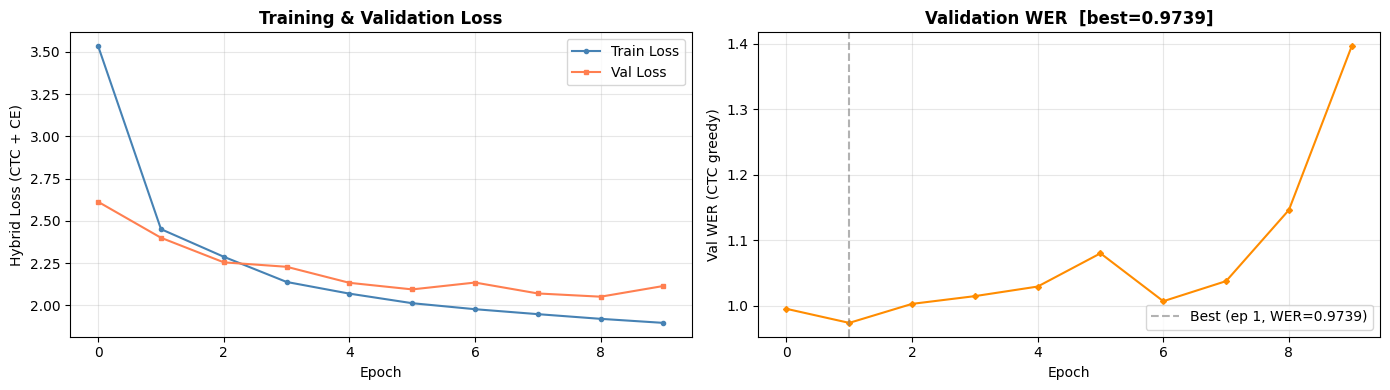

In [ ]:

import matplotlib.pyplot as plt


def plot_training_curves(history: Dict[str, List[float]], save_path: str = None):
    if not history or len(history.get('train_loss', [])) == 0:
        print('No training history to plot.')
        return

    epochs = range(len(history['train_loss']))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, history['train_loss'], 'o-', markersize=3,
                 color='steelblue', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   's-', markersize=3,
                 color='coral',    label='Val Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Hybrid Loss (CTC + CE)')
    axes[0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['val_wer'], 'D-', markersize=3, color='darkorange')
    best_ep  = int(np.argmin(history['val_wer']))
    best_wer = history['val_wer'][best_ep]
    axes[1].axvline(best_ep, color='gray', linestyle='--', alpha=0.6,
                    label=f'Best (ep {best_ep}, WER={best_wer:.4f})')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val WER (CTC greedy)')
    axes[1].set_title(f'Validation WER  [best={best_wer:.4f}]', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Curves saved → {save_path}')
    plt.show()


if trainer is not None:
    plot_training_curves(trainer.history, '/kaggle/working/training_curves.png')
else:
    print('trainer not available (RUN_TRAINING=False). Skipping plot.')